# Franchise exploration — TMDB

**Why this notebook:** the assigned `Movie_50k.csv` doesn't carry budget / revenue / collection info, so a franchise-trajectory analysis isn't feasible there. We pivot to TMDB's metadata dump, which gives us `belongs_to_collection`, `budget`, `revenue` and `vote_average` per movie.

**Story we want to tell:**
1. How does **rating** evolve as a franchise releases more movies? (sequel decay?)
2. How does **revenue** evolve in the same way?
3. Does it depend on **genre**?
4. What franchise-level features best predict the rating of the **next** movie?
5. A few extras: time-gap effects, top franchises.

In [1]:
import sys, os, ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

sys.path.append("Predictor")
from data_loader import load_tmdb_data
from features import build_features
from model import train_model

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
})

TMDB_DIR = "tmdb-movie-metadata"

## Load & clean

Reuse the existing loader (parses `belongs_to_collection`, drops rows with missing budget/revenue/year/rating). Then keep franchises with at least 3 entries — anything shorter doesn't have a trajectory.

In [2]:
df = load_tmdb_data(TMDB_DIR)

# parse genres (stored as JSON-ish strings)
def parse_genres(x):
    try:
        return [g["name"] for g in ast.literal_eval(x)]
    except Exception:
        return []

raw = pd.read_csv(os.path.join(TMDB_DIR, "movies_metadata.csv"), low_memory=False)
raw = raw[["id", "genres"]].copy()
raw["id"] = pd.to_numeric(raw["id"], errors="coerce")
raw["genre_list"] = raw["genres"].apply(parse_genres)
df["id"] = pd.to_numeric(df["id"], errors="coerce")
df = df.merge(raw[["id", "genre_list"]], on="id", how="left")
df["primary_genre"] = df["genre_list"].apply(lambda xs: xs[0] if isinstance(xs, list) and xs else None)

# stable franchises
sizes = df.groupby("franchise_id").size()
df = df[df["franchise_id"].isin(sizes[sizes >= 3].index)].copy()

# sequence number within each franchise
df = df.sort_values(["franchise_id", "releaseYear"])
df["seq"] = df.groupby("franchise_id").cumcount() + 1

print("Movies:", len(df))
print("Franchises:", df["franchise_id"].nunique())
df.head(3)

Movies: 502
Franchises: 120


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,originalTitle,video,vote_average,vote_count,franchise_id,releaseYear,imdbRating,genre_list,primary_genre,seq
25,False,"{'id': 10, 'name': 'Star Wars Collection', 'po...",11000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",http://www.starwars.com/films/star-wars-episod...,11,tt0076759,en,Star Wars,Princess Leia is captured and held hostage by ...,...,Star Wars,False,8.1,6778.0,10.0,1977.0,8.1,"[Adventure, Action, Science Fiction]",Adventure,1
83,False,"{'id': 10, 'name': 'Star Wars Collection', 'po...",18000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",http://www.starwars.com/films/star-wars-episod...,1891,tt0080684,en,The Empire Strikes Back,"The epic saga continues as Luke Skywalker, in ...",...,The Empire Strikes Back,False,8.2,5998.0,10.0,1980.0,8.2,"[Adventure, Action, Science Fiction]",Adventure,2
87,False,"{'id': 10, 'name': 'Star Wars Collection', 'po...",32350000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",http://www.starwars.com/films/star-wars-episod...,1892,tt0086190,en,Return of the Jedi,As Rebel leaders map their strategy for an all...,...,Return of the Jedi,False,7.9,4763.0,10.0,1983.0,7.9,"[Adventure, Action, Science Fiction]",Adventure,3


## Plot 1 — Rating across franchise sequence

Each grey line = one franchise. Bold red line = mean rating at each sequence position (only positions with at least 5 franchises, to avoid the tail being dominated by one outlier franchise like *James Bond*).

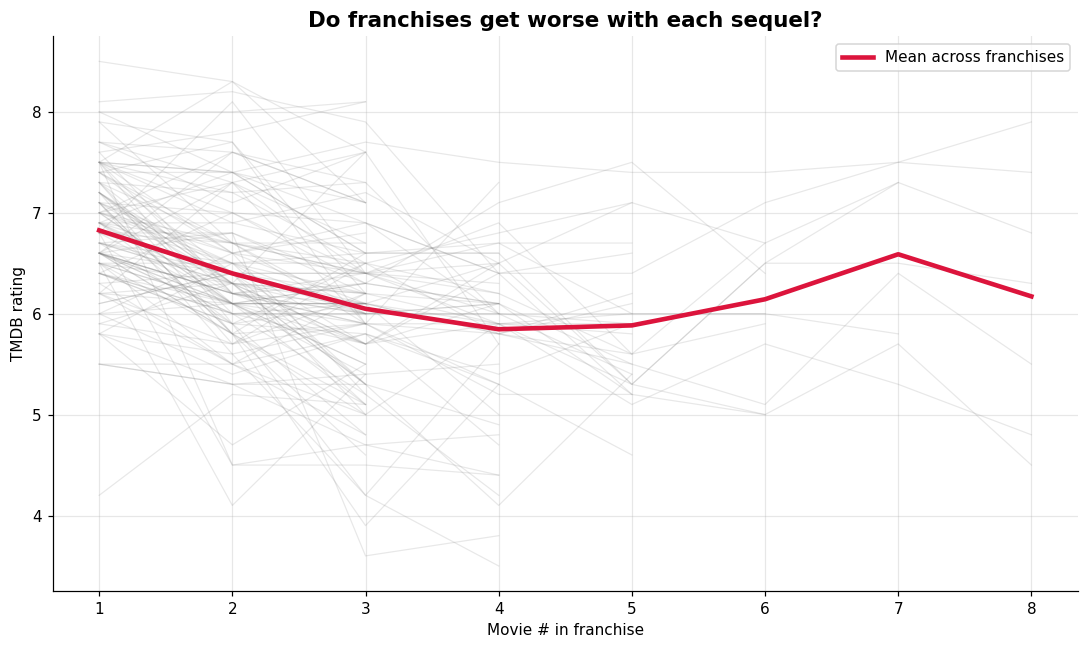

In [3]:
MAX_SEQ = 8  # cap the x-axis — most franchises have <= 8 entries
MIN_FRANCHISES_PER_POS = 5

fig, ax = plt.subplots(figsize=(10, 6))

for fid, g in df.groupby("franchise_id"):
    g = g[g["seq"] <= MAX_SEQ]
    ax.plot(g["seq"], g["imdbRating"], color="grey", alpha=0.18, linewidth=0.8)

agg = (df[df["seq"] <= MAX_SEQ]
       .groupby("seq")["imdbRating"]
       .agg(["mean", "count"]))
agg = agg[agg["count"] >= MIN_FRANCHISES_PER_POS]
ax.plot(agg.index, agg["mean"], color="crimson", linewidth=3, label="Mean across franchises")

ax.set_xlabel("Movie # in franchise")
ax.set_ylabel("TMDB rating")
ax.set_title("Do franchises get worse with each sequel?")
ax.set_xticks(range(1, MAX_SEQ + 1))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/franchise_rating_by_seq.png", dpi=150)
plt.show()

## Plot 2 — Revenue across franchise sequence

Same shape, log-scale y because revenue spans several orders of magnitude.

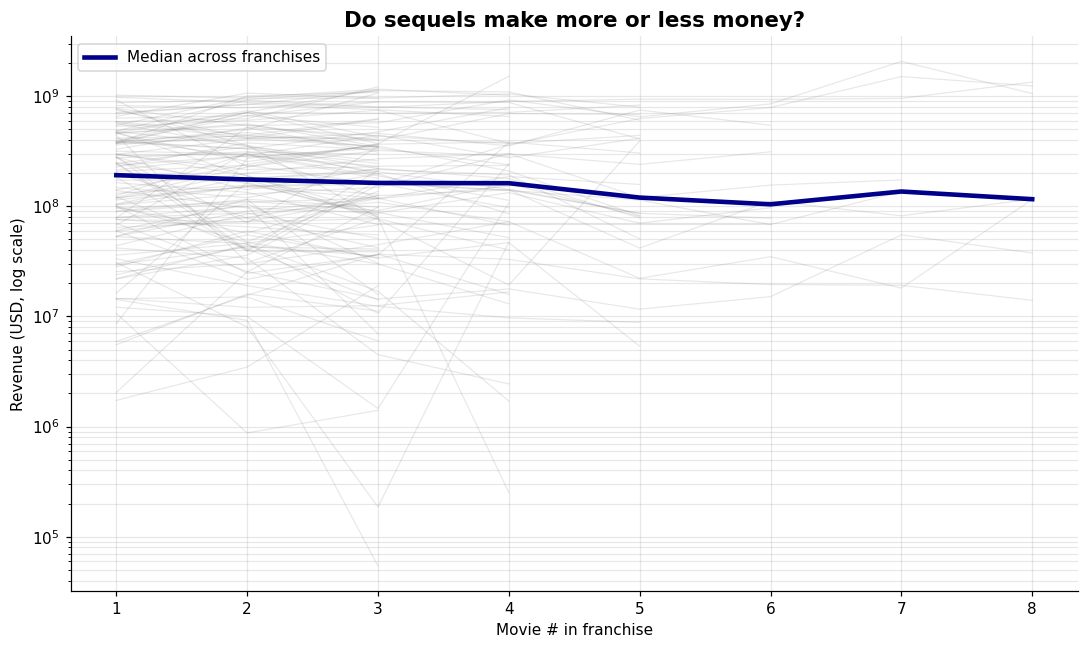

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

for fid, g in df.groupby("franchise_id"):
    g = g[(g["seq"] <= MAX_SEQ) & (g["revenue"] > 0)]
    ax.plot(g["seq"], g["revenue"], color="grey", alpha=0.18, linewidth=0.8)

agg = (df[(df["seq"] <= MAX_SEQ) & (df["revenue"] > 0)]
       .groupby("seq")["revenue"]
       .agg(["median", "count"]))
agg = agg[agg["count"] >= MIN_FRANCHISES_PER_POS]
ax.plot(agg.index, agg["median"], color="darkblue", linewidth=3, label="Median across franchises")

ax.set_yscale("log")
ax.set_xlabel("Movie # in franchise")
ax.set_ylabel("Revenue (USD, log scale)")
ax.set_title("Do sequels make more or less money?")
ax.set_xticks(range(1, MAX_SEQ + 1))
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("outputs/franchise_revenue_by_seq.png", dpi=150)
plt.show()

## Plot 3 — Genre split: rating across sequence

One line per top-N genre (a franchise is assigned to the most common primary genre across its movies).

Top genres: ['Action', 'Adventure', 'Comedy', 'Horror', 'Science Fiction']


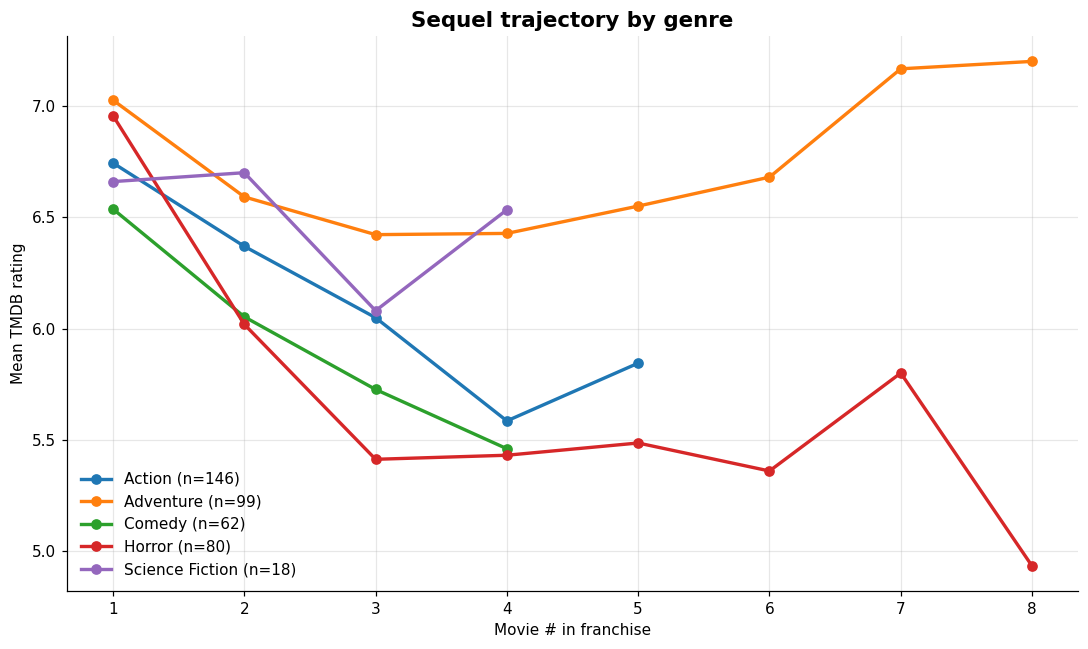

In [5]:
TOP_N_GENRES = 5

# franchise-level primary genre = mode of primary_genre across its movies
franchise_genre = (df.dropna(subset=["primary_genre"])
                     .groupby("franchise_id")["primary_genre"]
                     .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else None))
df["franchise_genre"] = df["franchise_id"].map(franchise_genre)

top_genres = (df.drop_duplicates("franchise_id")["franchise_genre"]
                .value_counts()
                .head(TOP_N_GENRES)
                .index.tolist())
print("Top genres:", top_genres)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10.colors

for i, gname in enumerate(top_genres):
    sub = df[(df["franchise_genre"] == gname) & (df["seq"] <= MAX_SEQ)]
    agg = sub.groupby("seq")["imdbRating"].agg(["mean", "count"])
    agg = agg[agg["count"] >= 3]  # lower threshold inside a single genre
    ax.plot(agg.index, agg["mean"], marker="o", color=colors[i], linewidth=2.2,
            label=f"{gname} (n={int(agg['count'].sum())})")

ax.set_xlabel("Movie # in franchise")
ax.set_ylabel("Mean TMDB rating")
ax.set_title("Sequel trajectory by genre")
ax.set_xticks(range(1, MAX_SEQ + 1))
ax.legend(loc="best", frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/franchise_rating_by_seq_by_genre.png", dpi=150)
plt.show()

## Plot 4 — Feature importance: what predicts the next movie's rating?

Using the existing `build_features` + `train_model` (random forest, target = rating of the next movie in the franchise given features computed from prior movies).

Test MAE: 0.468


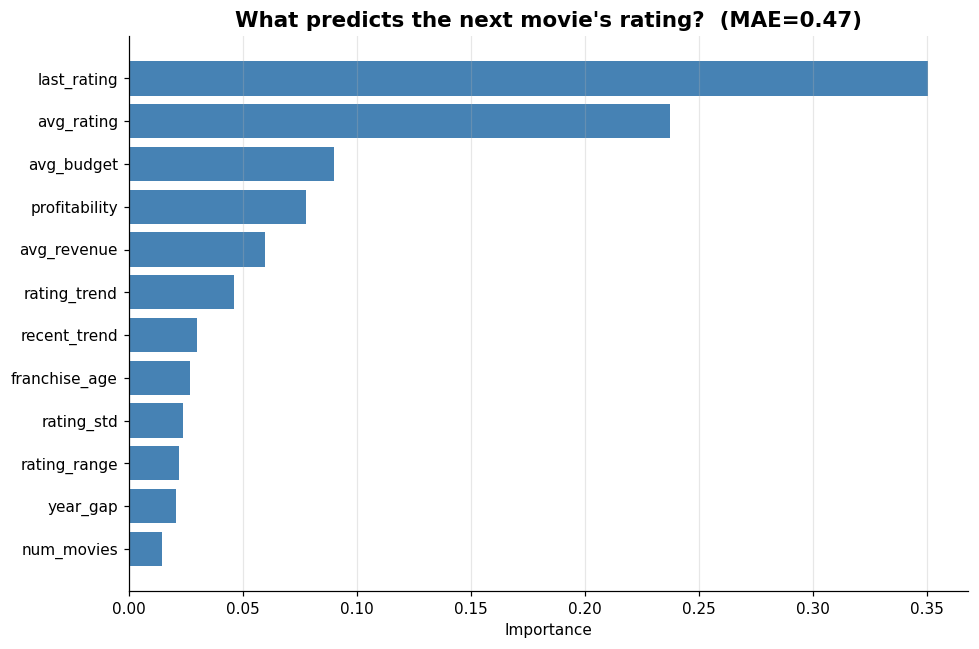

In [6]:
feat_df = build_features(df).dropna()
model, mae = train_model(feat_df)
print(f"Test MAE: {mae:.3f}")

X_cols = [c for c in feat_df.columns if c != "target"]
imp = pd.Series(model.feature_importances_, index=X_cols).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp.index, imp.values, color="steelblue")
ax.set_xlabel("Importance")
ax.set_title(f"What predicts the next movie's rating?  (MAE={mae:.2f})")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/feature_importance.png", dpi=150)
plt.show()

## Plot 5 — Sequel decay distribution

For every (movie #2, movie #3, ...) compute its rating change from the franchise's first movie. Boxplots show the spread — the typical sequel doesn't drop catastrophically, but the distribution widens.

/var/folders/z8/w64hfsr126b5rdd48x159fcm0000gn/T/ipykernel_98052/1978499827.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f"#{s}" for s in range(2, MAX_SEQ + 1)], showfliers=False)


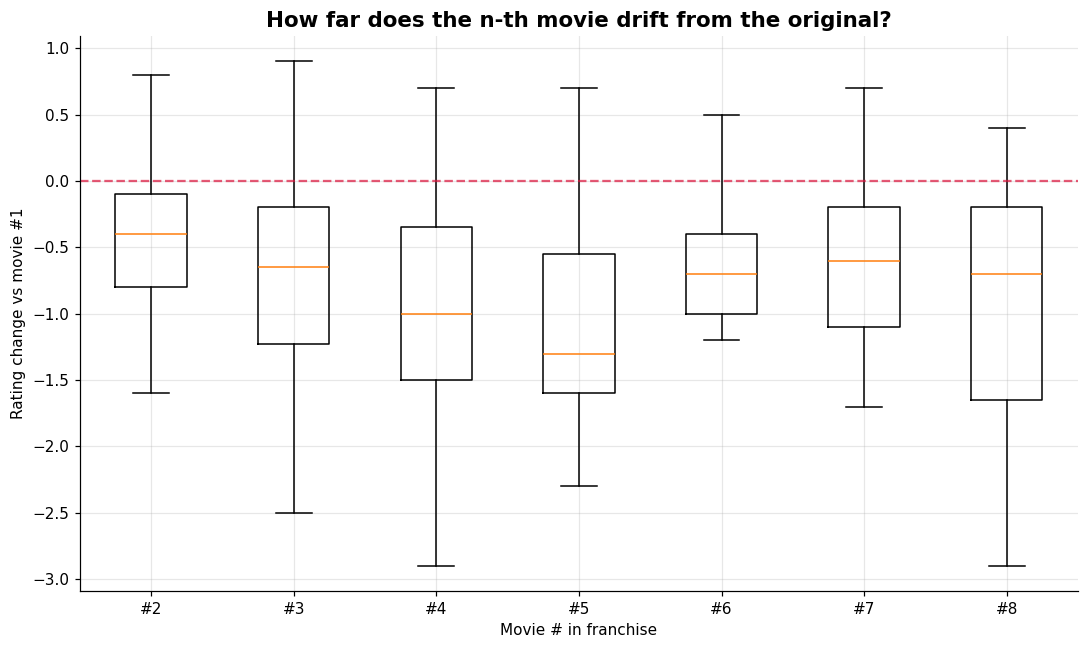

In [7]:
deltas = []
for fid, g in df.groupby("franchise_id"):
    g = g.sort_values("releaseYear")
    if len(g) < 2:
        continue
    base = g["imdbRating"].iloc[0]
    for i, row in enumerate(g.itertuples(), start=1):
        if i == 1:
            continue
        if i > MAX_SEQ:
            break
        deltas.append({"seq": i, "delta": row.imdbRating - base})

delta_df = pd.DataFrame(deltas)

fig, ax = plt.subplots(figsize=(10, 6))
data = [delta_df[delta_df["seq"] == s]["delta"].values for s in range(2, MAX_SEQ + 1)]
ax.boxplot(data, labels=[f"#{s}" for s in range(2, MAX_SEQ + 1)], showfliers=False)
ax.axhline(0, color="crimson", linestyle="--", alpha=0.7)
ax.set_xlabel("Movie # in franchise")
ax.set_ylabel("Rating change vs movie #1")
ax.set_title("How far does the n-th movie drift from the original?")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/sequel_decay.png", dpi=150)
plt.show()

## Plot 6 — Time gap effect: does waiting longer help or hurt the next movie?

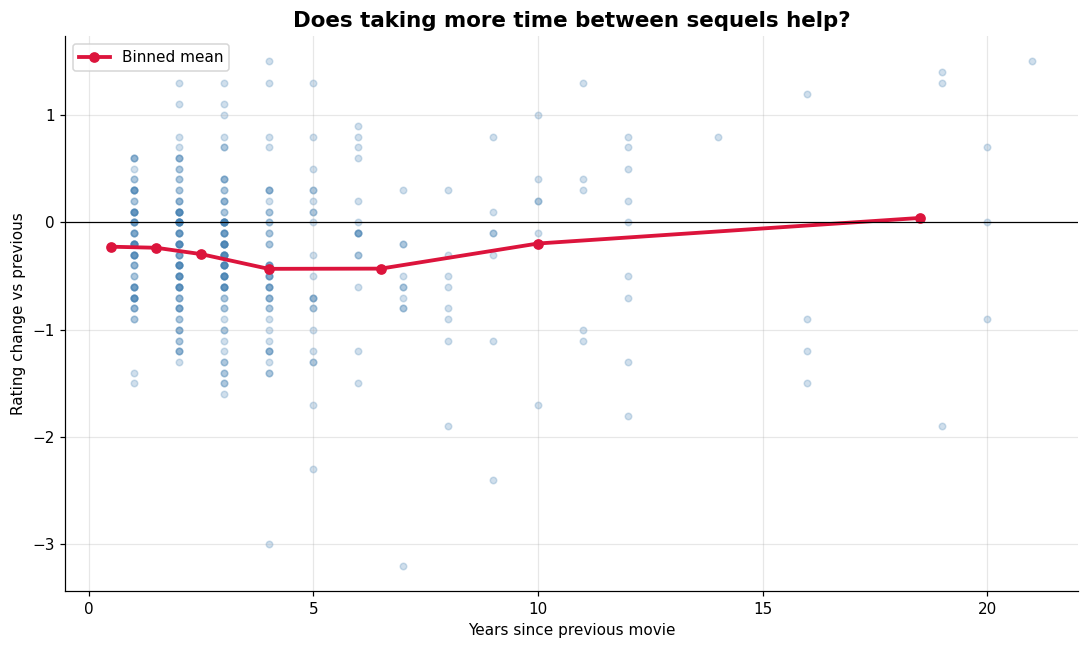

In [8]:
gaps = []
for fid, g in df.groupby("franchise_id"):
    g = g.sort_values("releaseYear").reset_index(drop=True)
    for i in range(1, len(g)):
        gap = g.loc[i, "releaseYear"] - g.loc[i-1, "releaseYear"]
        delta = g.loc[i, "imdbRating"] - g.loc[i-1, "imdbRating"]
        if 0 < gap <= 25:
            gaps.append({"gap": gap, "delta": delta})

gap_df = pd.DataFrame(gaps)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(gap_df["gap"], gap_df["delta"], alpha=0.25, s=18, color="steelblue")

# binned mean line
bins = pd.cut(gap_df["gap"], bins=[0, 1, 2, 3, 5, 8, 12, 25])
binned = gap_df.groupby(bins, observed=True)["delta"].mean()
centers = [iv.mid for iv in binned.index]
ax.plot(centers, binned.values, color="crimson", linewidth=2.5, marker="o", label="Binned mean")
ax.axhline(0, color="black", linewidth=0.8)

ax.set_xlabel("Years since previous movie")
ax.set_ylabel("Rating change vs previous")
ax.set_title("Does taking more time between sequels help?")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/time_gap_vs_rating.png", dpi=150)
plt.show()

## Plot 7 — Top franchises: revenue vs rating

Bubble size = number of movies in the franchise. Useful for spotting both prestige (high rating) and cash-cow (high revenue) franchises.

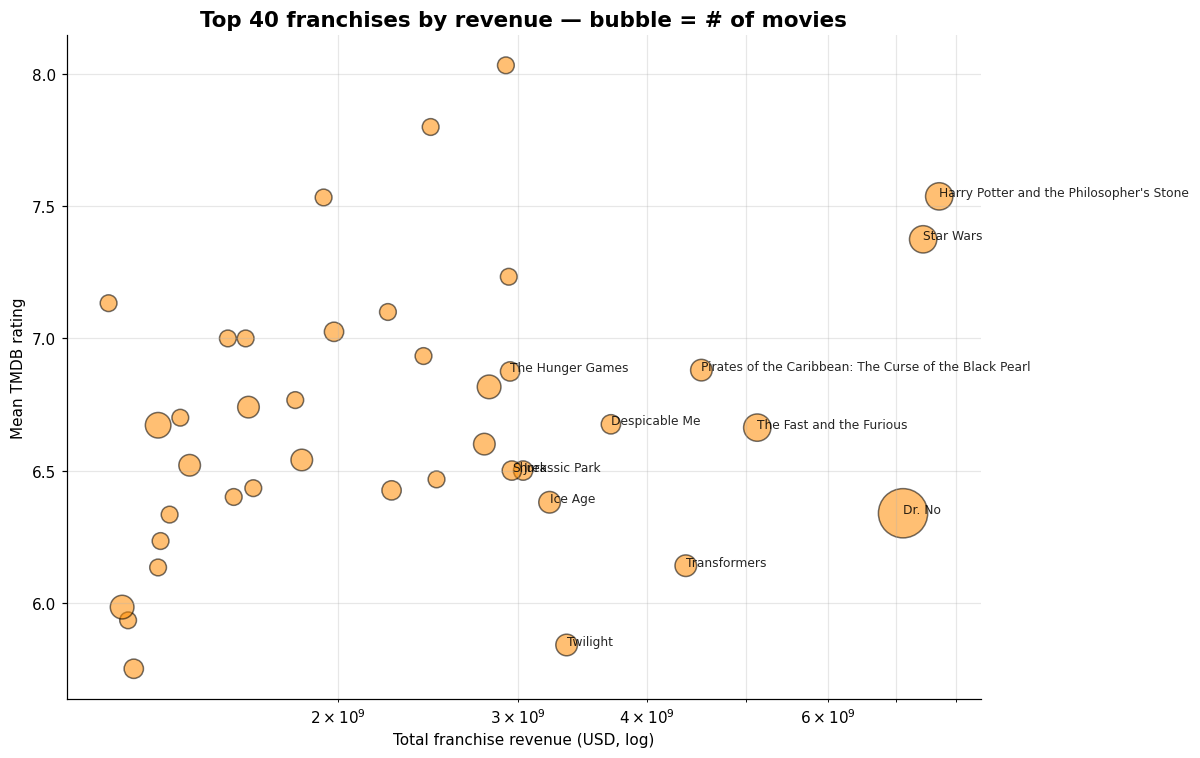

In [9]:
agg = (df.groupby("franchise_id")
         .agg(rating=("imdbRating", "mean"),
              revenue=("revenue", "sum"),
              n=("id", "size"),
              name=("originalTitle", "first"))
         .reset_index())
agg = agg[agg["revenue"] > 0]

top = agg.nlargest(40, "revenue")

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(top["revenue"], top["rating"], s=top["n"]*40, alpha=0.55, color="darkorange", edgecolor="black")
ax.set_xscale("log")
for _, r in top.head(12).iterrows():
    ax.annotate(r["name"], (r["revenue"], r["rating"]), fontsize=8, alpha=0.85)
ax.set_xlabel("Total franchise revenue (USD, log)")
ax.set_ylabel("Mean TMDB rating")
ax.set_title("Top 40 franchises by revenue — bubble = # of movies")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("outputs/top_franchises_revenue_vs_rating.png", dpi=150)
plt.show()

## Takeaways for the poster

- **Mean rating mostly holds across the first ~4 movies** but starts to drift past that — Plot 1 + Plot 5.
- **Revenue trajectories vary wildly** — Plot 2 — the median sequel doesn't outperform the original consistently, but a small number of franchises grow massively.
- **Genre matters** — Plot 3 — some genres (e.g., Action) hold up better through sequels than others.
- **Strongest predictor** of the next movie's rating is the franchise's existing rating profile, not budget/revenue — Plot 4.
- **Time between movies** has only a weak effect on rating change — Plot 6.